In [51]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#**Data Pre-Processing**
- **Data imputation**: The Prima Indians Diabetes Dataset contains biologically implausible zero values (eg. blood pressure of 0). To address this, these zero datapoints were treated as missing values and replaced with the mean of the respective feature.

In [52]:
diabetes = pd.read_csv('diabetes.csv')

cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

diabetes[cols] = diabetes[cols].replace(0, np.nan)
diabetes.fillna(diabetes.mean(), inplace=True)

print(diabetes.shape)
print(diabetes.head())

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0     6.000000    148.0           72.0       35.00000  155.548223  33.6   
1     1.000000     85.0           66.0       29.00000  155.548223  26.6   
2     8.000000    183.0           64.0       29.15342  155.548223  23.3   
3     1.000000     89.0           66.0       23.00000   94.000000  28.1   
4     4.494673    137.0           40.0       35.00000  168.000000  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


#**Data Preparation**
- The dataset was normalized to account for large differences in feature scaling.
- The target variable (y) was reshaped to (614,1) to match the model's output dimensions.

In [53]:
X = diabetes.drop('Outcome', axis=1)
y = diabetes['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
X_train = torch.tensor(X_train)
X_test = torch.tensor(X_test)

X_train = X_train.float()
X_test = X_test.float()

y_train = torch.tensor(y_train.values)
y_test = torch.tensor(y_test.values)

y_train = y_train.view(-1,1).float()
y_test = y_test.view(-1,1).float()

print(f'X_train, X_test shape: {X_train.shape, X_test.shape}')
print(f'y_train, y_test shape: {y_train.shape, y_test.shape}')

X_train, X_test shape: (torch.Size([614, 8]), torch.Size([154, 8]))
y_train, y_test shape: (torch.Size([614, 1]), torch.Size([154, 1]))


#**Model Architecture**
- The number of layers, learning rate, number of epochs were selected based on prior experimentation (see Notes section).
- BCEWithLogitsLoss was used as the loss function, as the task is a binary classification problem (presence vs absence of diabetes).

In [56]:
class MultiLayerModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(8,16),
        nn.ReLU(),
        nn.Linear(16,16),
        nn.ReLU(),
        nn.Linear(16,1),
    )

  def forward(self,x):
    return self.network(x)

model = MultiLayerModel()
print(model)

MultiLayerModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [57]:
learning_rate = 0.01

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = torch.nn.BCEWithLogitsLoss()

In [58]:
epochs = 100

losses = []

for epoch in range(epochs):
  # 1) Forward propagation
  y_hat = model(X_train)

  # 2) Calculate loss
  loss = loss_fn(y_hat, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  losses.append(loss.item())

  if epoch % 10 == 0:
    print(f'Epoch {epoch}: Loss = {loss.item()}')

Epoch 0: Loss = 0.662045955657959
Epoch 10: Loss = 0.4904783070087433
Epoch 20: Loss = 0.44877469539642334
Epoch 30: Loss = 0.42910051345825195
Epoch 40: Loss = 0.41091880202293396
Epoch 50: Loss = 0.3952145278453827
Epoch 60: Loss = 0.37954553961753845
Epoch 70: Loss = 0.3632112145423889
Epoch 80: Loss = 0.3479611873626709
Epoch 90: Loss = 0.3324386775493622


#**Visualizing Training Loss vs Epochs**

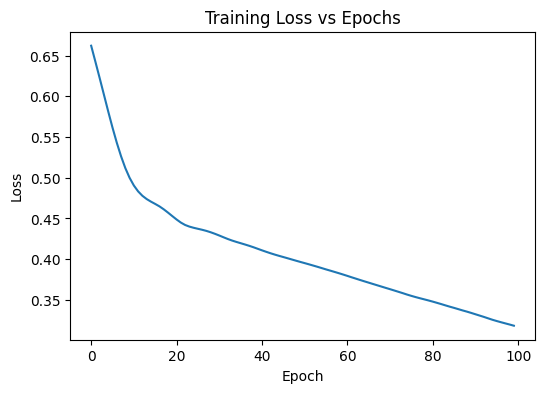

In [59]:
plot = plt.figure(figsize=(6,4))
plt.plot(losses)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Epochs')
plt.show()

#**Model Performance Evaluation**

In [60]:
model.eval()

with torch.no_grad():
    y_pred_logits = model(X_test)
    y_pred_probs = torch.sigmoid(y_pred_logits)
    y_pred = (y_pred_probs >= 0.5).float()

    accuracy = (y_pred == y_test).float().mean()

print(f"Test Accuracy: {accuracy.item():.4f}")

Test Accuracy: 0.7403


In [61]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("Unique preds:", y_pred.unique())
print("First 20 preds:", y_pred[:20].T)
print("First 20 labels:", y_test[:20].T)

Train size: torch.Size([614, 8])
Test size: torch.Size([154, 8])
Unique preds: tensor([0., 1.])
First 20 preds: tensor([[1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0.,
         1., 1.]])
First 20 labels: tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0.,
         1., 1.]])


#**Model Testing with Sample Data**
- This sample input was designed to represent an individual at high risk of diabetes.
- The model correctly classified the sample as diabetic, with a predicted probability of 95%.

In [62]:
sample = [[
    6,      # Pregnancies
    165,    # Glucose (high)
    85,     # BloodPressure
    30,     # SkinThickness
    200,    # Insulin (high)
    33.6,   # BMI (overweight)
    0.627,  # DiabetesPedigreeFunction
    50      # Age
]]

sample_scaled = scaler.transform(sample)
sample_tensor = torch.tensor(sample_scaled).float()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [63]:
model.eval()
with torch.no_grad():
  logits = model(sample_tensor)
  prob = torch.sigmoid(logits)

print(f'Diabetes probability: {prob.item():.4f}')

Diabetes probability: 0.9537
